# EDA for Top 200 Spotify Songs dataset
- https://www.kaggle.com/datasets/brunoalarcon123/top-200-spotify-songs-dataset

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from pathlib import Path

# Mina konstanter rörs ej (Skrivs med ALL CAPS i Python)
DATA_PATH = Path.cwd().parent / "data"
BRONZE_PATH = DATA_PATH / "bronze"
SILVER_PATH = DATA_PATH / "silver"
FILE_PATH = BRONZE_PATH / "Spotify_Top_200_Songs.csv"

df = pd.read_csv(FILE_PATH, delimiter=";")

## analysis

In [68]:
df.shape
print(f"The Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

The Dataset contains 651936 rows and 20 columns.


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 651936 entries, 0 to 651935
Data columns (total 20 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Rank                              651936 non-null  int64  
 1   Title                             651936 non-null  str    
 2   Artists                           651936 non-null  str    
 3   Date                              651936 non-null  str    
 4   Danceability                      651936 non-null  float64
 5   Energy                            651936 non-null  float64
 6   Loudness                          651936 non-null  float64
 7   Speechiness                       651936 non-null  float64
 8   Acousticness                      651936 non-null  float64
 9   Instrumentalness                  651936 non-null  float64
 10  Valence                           651936 non-null  float64
 11  # of Artist                       651936 non-null  str    
 12 

In [70]:
df.head()

,Rank,Title,Artists,Date,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,# of Artist,Artist (Ind.),# of Nationality,Nationality,Continent,Points (Total),Points (Ind for each Artist/Nat),id,Song URL
0,1,Ella Baila Sola,"Eslabon Armado, Peso Pluma",29/05/2023,0.668,0.758,-5176.0,0.033,0.483,0.000,0.834,Artist 1,Eslabon Armado,Nationality 1,Mexico,Latin-America,200,100.0,3qQbCzHBycnDpGskqOWY0E,https://open.spotify.com/track/3qQbCzHBycnDpGs...
1,1,Ella Baila Sola,"Eslabon Armado, Peso Pluma",29/05/2023,0.668,0.758,-5176.0,0.033,0.483,0.000,0.834,Artist 2,Peso Pluma,Nationality 2,Mexico,Latin-America,200,100.0,3qQbCzHBycnDpGskqOWY0E,https://open.spotify.com/track/3qQbCzHBycnDpGs...
2,2,WHERE SHE GOES,Bad Bunny,29/05/2023,0.652,0.800,-4019.0,0.061,0.143,0.629,0.234,Artist 1,Bad Bunny,Nationality 1,Puerto Rico,Latin-America,199,199.0,7ro0hRteUMfnOioTFI5TG1,https://open.spotify.com/track/7ro0hRteUMfnOio...
3,3,La Bebe - Remix,"Yng Lvcas, Peso Pluma",29/05/2023,0.812,0.479,-5678.0,0.333,0.213,0.000,0.559,Artist 1,Yng Lvcas,Nationality 1,Mexico,Latin-America,198,99.0,2UW7JaomAMuX9pZrjVpHAU,https://open.spotify.com/track/2UW7JaomAMuX9pZ...
4,3,La Bebe - Remix,"Yng Lvcas, Peso Pluma",29/05/2023,0.812,0.479,-5678.0,0.333,0.213,0.000,0.559,Artist 2,Peso Pluma,Nationality 2,Mexico,Latin-America,198,99.0,2UW7JaomAMuX9pZrjVpHAU,https://open.spotify.com/track/2UW7JaomAMuX9pZ...


In [71]:
df.describe()

,Rank,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,Points (Total),Points (Ind for each Artist/Nat)
count,651936.000000,651936.000000,651936.000000,651936.000000,651936.000000,651936.000000,651936.000000,651936.000000,651936.000000,651936.000000
mean,100.407782,0.697730,0.652049,-5295.645217,0.109946,0.230694,0.007647,0.523134,100.592218,72.391141
std,57.406664,0.133186,0.155684,2785.261321,0.096841,0.230710,0.054724,0.223926,57.406664,54.227892
min,1.000000,0.073000,0.005000,-34475.000000,0.022000,0.000000,0.000000,0.026000,1.000000,0.200000
25%,51.000000,0.617000,0.549000,-6825.000000,0.045000,0.048000,0.000000,0.356000,51.000000,28.000000
50%,100.000000,0.719000,0.671000,-5206.000000,0.068000,0.152000,0.000000,0.521000,101.000000,60.000000
75%,150.000000,0.793000,0.771000,-3885.000000,0.136000,0.349000,0.000000,0.696000,150.000000,104.000000
max,200.000000,0.985000,0.996000,1509.000000,0.966000,0.994000,0.956000,0.982000,200.000000,200.000000


In [72]:
df_many_artists = df[(df['Title'] == 'Thunderclouds') & (df['Date'] == '16/03/2019')]

df_many_artists

,Rank,Title,Artists,Date,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,# of Artist,Artist (Ind.),# of Nationality,Nationality,Continent,Points (Total),Points (Ind for each Artist/Nat),id,Song URL
431641,195,Thunderclouds,"Sia, Diplo, Labrinth, LSD",16/03/2019,0.691,0.716,-5985.0,0.035,0.009,0.0,0.507,Artist 1,Sia,Nationality 1,Australia,Oceania,6,2.0,2c7GlMNmF7pbohjykutmLP,https://open.spotify.com/track/2c7GlMNmF7pbohj...
431642,195,Thunderclouds,"Sia, Diplo, Labrinth, LSD",16/03/2019,0.691,0.716,-5985.0,0.035,0.009,0.0,0.507,Artist 2,Diplo,Nationality 2,United States,Anglo-America,6,2.0,2c7GlMNmF7pbohjykutmLP,https://open.spotify.com/track/2c7GlMNmF7pbohj...
431643,195,Thunderclouds,"Sia, Diplo, Labrinth, LSD",16/03/2019,0.691,0.716,-5985.0,0.035,0.009,0.0,0.507,Artist 3,Labrinth,Nationality 3,United Kingdom,Europe,6,2.0,2c7GlMNmF7pbohjykutmLP,https://open.spotify.com/track/2c7GlMNmF7pbohj...
431644,195,Thunderclouds,"Sia, Diplo, Labrinth, LSD",16/03/2019,0.691,0.716,-5985.0,0.035,0.009,0.0,0.507,Artist 4,LSD,Nationality 4,Unknown,Unknown,6,2.0,2c7GlMNmF7pbohjykutmLP,https://open.spotify.com/track/2c7GlMNmF7pbohj...


In [73]:
query = """
    SELECT 
        Title, 
        COUNT(DISTINCT Nationality) AS num_nations,
        STRING_AGG(DISTINCT Nationality, ', ') AS collaborating_nations
    FROM df
    GROUP BY Title
    HAVING num_nations > 1
    ORDER BY num_nations DESC
    LIMIT 10
"""

collabs_df = duckdb.sql(query).df()
collabs_df

,Title,num_nations,collaborating_nations
0,Ruway,6,"Puerto Rico, Norway, Colombia, Brazil, United ..."
1,Intro,5,"South Korea, United States, United Kingdom, Ca..."
2,Instagram,5,"Puerto Rico, France, Belgium, Netherlands, Dom..."
3,On My Way,5,"Norway, United States, Puerto Rico, United Kin..."
4,All Night,5,"Norway, Austria, United Kingdom, United States..."
5,Stay,5,"Russia, South Korea, United States, Canada, Ba..."
6,Bum Bum Tam Tam,5,"Spain, United Kingdom, Brazil, Colombia, Unite..."
7,Déjate Llevar,5,"Dominican Republic, Germany, Colombia, Spain, ..."
8,Ferrari,5,"Germany, United States, Puerto Rico, United Ki..."
9,All Falls Down,4,"United States, Sweden, Norway, United Kingdom"


## Summary analysis
- The Dataset contains 651936 rows and 20 columns. With top 200 songs/day from January 1, 2017 to May 29, 2023.
- Row analysis: Each row is the ranking for that day. The list is also divided so if a group consists of 3 artists then the ranking for that day will have 3 rows as each artist gets their own row.

### Table content of the file

| Column | Scale | type | Meaning |
| :--- | :--- | :--- | :--- |
| **Rank** | 1 to 200 | *(type: int)* | Rank of the song on that specific date |
| **Title** | Category | *(type: str)* | Title of song |
| **Artists** | Category | *(type: str)* | Artist or group name |
| **Date** | 2017 - 2023 | *(type: str)* | Rank of the song on that specific date |
| **Danceability** | 0 to 1 (%) | *(type: float)* | Describes how suitable a track is for dancing |
| **Energy** | 0 to 1 (%) | *(type: float)* | Represents a perceptual measure of intensity and activity. Energetic tracks feel fast, loud and noisy. |
| **Loudness** | -60 to 2 | *(type: float)* | The overall loudness of a track in dBFS (Decibels relative to Full Scale) |
| **Speechiness** | 0 to 1 (%) | *(type: float)* | Detects the presence of spoken words in a track. |
| **Acousticness** | 0 to 1 (%) | *(type: float)* | Describes whether a track uses only or primarily instruments that produce sound through acoustic means. |
| **Valence** | 0 to 1 (%) | *(type: float)* | Describes the musical positiveness of a track |
| **# of Artist** | Category | *(type: str)* | Describes the musical positiveness of a track |
| **Artist (Ind.)** | Category | *(type: str )* | In colaboration witch artist in the group |
| **# of Nationality** | 1 =< | *(type: str )* | In colaboration witch number in the group the nationality comes from |
| **Nationality** | Category | *(type: str )* | The land the artist comes from |
| **Continent** | Category | *(type: str )* | The continent the artist comes from |
| **Points (Total)** | 1 to 200 | *(type: int)* | Scoring where 200 position gives 1 point and 1 gives 200 points|
| **Points (Ind for each Artist/Nat)** | 1 to 200 | *(type: float)* | If song is a collaborative effort points are split up. If 2 artist gets nr 1 they are both going to get 100 points |
| **id** | uniqe | *(type: str)* | Uniqe spotify-id  |
| **Song URL** | uniqe | *(type: str)* | Songs URL |

## Transformation

### Findings
- **Duplicates:** Remove duplicates rows
- **Columns:** Change these so that they do not contain spaces, special signs.
- **Date:** Was a str. Needs to be transformed to Date
- **Loudness:** Should be beetween -60 and 2 since it according to metadata should be decibel. But the numbers are between -34475 and 1509. Should be -34.475 and 1.509 a decimal error
- **# of Artist:** Is a str with "Artist 1". Transform this to just 1 type Int.
- **# of Nationality:** Since we already have this data in # of Artist, we don't need this.

In [74]:
df.head()

,Rank,Title,Artists,Date,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,# of Artist,Artist (Ind.),# of Nationality,Nationality,Continent,Points (Total),Points (Ind for each Artist/Nat),id,Song URL
0,1,Ella Baila Sola,"Eslabon Armado, Peso Pluma",29/05/2023,0.668,0.758,-5176.0,0.033,0.483,0.000,0.834,Artist 1,Eslabon Armado,Nationality 1,Mexico,Latin-America,200,100.0,3qQbCzHBycnDpGskqOWY0E,https://open.spotify.com/track/3qQbCzHBycnDpGs...
1,1,Ella Baila Sola,"Eslabon Armado, Peso Pluma",29/05/2023,0.668,0.758,-5176.0,0.033,0.483,0.000,0.834,Artist 2,Peso Pluma,Nationality 2,Mexico,Latin-America,200,100.0,3qQbCzHBycnDpGskqOWY0E,https://open.spotify.com/track/3qQbCzHBycnDpGs...
2,2,WHERE SHE GOES,Bad Bunny,29/05/2023,0.652,0.800,-4019.0,0.061,0.143,0.629,0.234,Artist 1,Bad Bunny,Nationality 1,Puerto Rico,Latin-America,199,199.0,7ro0hRteUMfnOioTFI5TG1,https://open.spotify.com/track/7ro0hRteUMfnOio...
3,3,La Bebe - Remix,"Yng Lvcas, Peso Pluma",29/05/2023,0.812,0.479,-5678.0,0.333,0.213,0.000,0.559,Artist 1,Yng Lvcas,Nationality 1,Mexico,Latin-America,198,99.0,2UW7JaomAMuX9pZrjVpHAU,https://open.spotify.com/track/2UW7JaomAMuX9pZ...
4,3,La Bebe - Remix,"Yng Lvcas, Peso Pluma",29/05/2023,0.812,0.479,-5678.0,0.333,0.213,0.000,0.559,Artist 2,Peso Pluma,Nationality 2,Mexico,Latin-America,198,99.0,2UW7JaomAMuX9pZrjVpHAU,https://open.spotify.com/track/2UW7JaomAMuX9pZ...


In [78]:
df = pd.read_csv(FILE_PATH, delimiter=";")

print(f"Rows before cleaning: {len(df)}")

# Cleaning Column Names
df.columns = (df.columns
                .str.lower()
                .str.replace(r'[^\w\s]', '', regex=True)
                .str.strip()
                .str.replace(' ', '_')
                .str.replace('__', '_'))

# Correction of Decimal-error in Loudness values
df['loudness'] = df['loudness'] / 1000

# Transform date column to datetime format
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Transform "# of Artist" to "artist_index" (type: int)
df['artist_index'] = df['of_artist'].str.replace('Artist ', '').astype(int)

# Trimming whitespace from text columns
text_columns = ['title', 'artists', 'nationality', 'continent']
for col in text_columns:
    df[col] = df[col].str.strip()

# Drop columns that are not needed for analysis
columns_to_drop = ['of_nationality', 'of_artist']
df = df.drop(columns=columns_to_drop, errors='ignore')

# Remove duplicates if any
df = df.drop_duplicates()

print(f"Rows after cleaning: {len(df)}")
print("DataCleaning complete! Loading data to parquet file.")
df.to_parquet(SILVER_PATH / "spotify_top_200_cleaned.parquet", index=False)

df.head()

Rows before cleaning: 651936
Rows after cleaning: 651936
DataCleaning complete! Loading data to parquet file.


,rank,title,artists,date,danceability,energy,loudness,speechiness,acousticness,instrumentalness,valence,artist_ind,nationality,continent,points_total,points_ind_for_each_artistnat,id,song_url,artist_index
0,1,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2023-05-29,0.668,0.758,-5.176,0.033,0.483,0.000,0.834,Eslabon Armado,Mexico,Latin-America,200,100.0,3qQbCzHBycnDpGskqOWY0E,https://open.spotify.com/track/3qQbCzHBycnDpGs...,1
1,1,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2023-05-29,0.668,0.758,-5.176,0.033,0.483,0.000,0.834,Peso Pluma,Mexico,Latin-America,200,100.0,3qQbCzHBycnDpGskqOWY0E,https://open.spotify.com/track/3qQbCzHBycnDpGs...,2
2,2,WHERE SHE GOES,Bad Bunny,2023-05-29,0.652,0.800,-4.019,0.061,0.143,0.629,0.234,Bad Bunny,Puerto Rico,Latin-America,199,199.0,7ro0hRteUMfnOioTFI5TG1,https://open.spotify.com/track/7ro0hRteUMfnOio...,1
3,3,La Bebe - Remix,"Yng Lvcas, Peso Pluma",2023-05-29,0.812,0.479,-5.678,0.333,0.213,0.000,0.559,Yng Lvcas,Mexico,Latin-America,198,99.0,2UW7JaomAMuX9pZrjVpHAU,https://open.spotify.com/track/2UW7JaomAMuX9pZ...,1
4,3,La Bebe - Remix,"Yng Lvcas, Peso Pluma",2023-05-29,0.812,0.479,-5.678,0.333,0.213,0.000,0.559,Peso Pluma,Mexico,Latin-America,198,99.0,2UW7JaomAMuX9pZrjVpHAU,https://open.spotify.com/track/2UW7JaomAMuX9pZ...,2


In [ ]:
# Most unique songs by artists
unique_songs = """
    SELECT
        artists,
        COUNT(DISTINCT title) AS unique_songs
    FROM '../data/silver/spotify_top_200_cleaned.parquet'
    GROUP BY artists
    ORDER BY unique_songs DESC
    LIMIT 10
"""

# duckdb.sql() fattar automatiskt att 'df' är din Pandas-tabell
top_artists = duckdb.sql(unique_songs).df()
top_artists

,artists,unique_songs
0,Taylor Swift,154
1,Drake,109
2,BTS,89
3,Juice WRLD,75
4,Future,73
5,Ed Sheeran,68
6,Eminem,64
7,Lil Uzi Vert,59
8,Ariana Grande,56
9,Bad Bunny,53


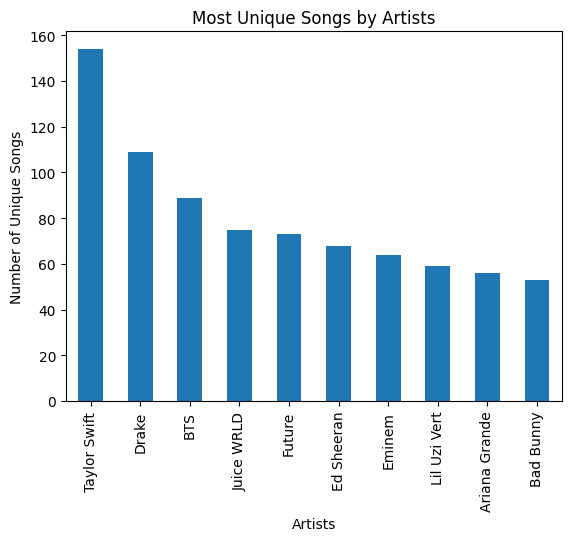

In [88]:
ax =top_artists.plot(
    kind='bar',
    x='artists',
    y='unique_songs',
    legend=False,
    title='Most Unique Songs by Artists',
    xlabel='Artists',
    ylabel='Number of Unique Songs')

fig = ax.get_figure()
fig.savefig("most_unique_songs_by_artists.png", dpi=300)

In [81]:
# How does the average loudness change over the years?
loudness_trend = """
    SELECT 
        YEAR(date) AS release_year, 
        ROUND(AVG(loudness), 2) AS avg_loudness
    FROM '../data/silver/spotify_top_200_cleaned.parquet'
    GROUP BY release_year
    ORDER BY release_year
"""

loudness_trend = duckdb.sql(loudness_trend).df()
loudness_trend

,release_year,avg_loudness
0,2017,-5.28
1,2018,-5.19
2,2019,-5.29
3,2020,-5.38
4,2021,-5.43
5,2022,-5.28
6,2023,-5.10


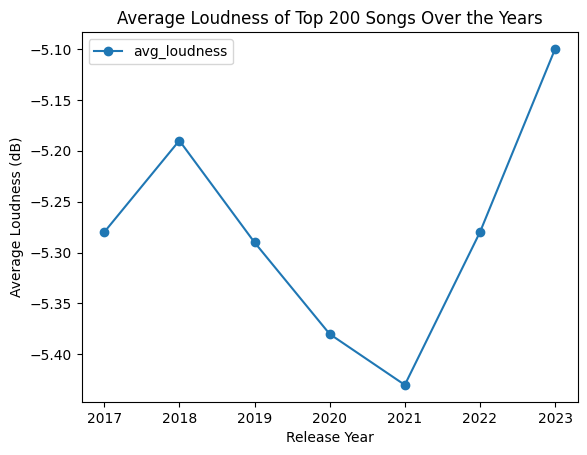

In [89]:
ax = loudness_trend.plot(x='release_year', y='avg_loudness', marker='o', title='Average Loudness of Top 200 Songs Over the Years', xlabel='Release Year', ylabel='Average Loudness (dB)')

fig = ax.get_figure()
fig.savefig("average_loudness_over_years.png", dpi=300)